In [27]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [28]:
BASE_DIR = os.path.dirname(os.getcwd())
WEIGHT_DIR = os.path.join(BASE_DIR, "models", "weights")
SEED = 42
DATASET= os.path.join(BASE_DIR, "data", "pneumonia_patients.csv")

In [29]:
#LOAD DATASET
df = pd.read_csv(DATASET)

print(f"Shape      : {df.shape}")
print(f"Columns    : {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Shape      : (2000, 17)
Columns    : ['patient_id', 'age', 'gender', 'temperature_celsius', 'spo2_percent', 'respiratory_rate', 'wbc_count_x10', 'cough_duration_days', 'chest_pain', 'smoker', 'diabetes', 'hypertension', 'prior_pneumonia', 'copd', 'confusion', 'blood_pressure_systolic', 'severity']

First 5 rows:


,patient_id,age,gender,temperature_celsius,spo2_percent,respiratory_rate,wbc_count_x10,cough_duration_days,chest_pain,smoker,diabetes,hypertension,prior_pneumonia,copd,confusion,blood_pressure_systolic,severity
0,PNM0001,77,Female,39.0,85.0,28,15.5,12,1,0,0,0,0,0,1,107.0,1
1,PNM0002,21,Male,37.9,96.0,20,7.4,7,0,1,0,0,0,0,0,132.0,0
2,PNM0003,57,Male,39.0,96.0,20,7.0,1,1,1,1,0,0,0,0,135.0,0
3,PNM0004,33,Female,38.4,99.0,12,6.5,9,1,1,0,1,1,0,0,133.0,0
4,PNM0005,63,Male,39.9,92.0,37,18.6,12,1,0,0,0,0,0,0,96.0,1


In [30]:
#BASIC INFO
print("Data types:")
print(df.dtypes)
print("\nSummary statistics:")
df.describe()

Data types:
patient_id                  object
age                          int64
gender                      object
temperature_celsius        float64
spo2_percent               float64
respiratory_rate             int64
wbc_count_x10              float64
cough_duration_days          int64
chest_pain                   int64
smoker                       int64
diabetes                     int64
hypertension                 int64
prior_pneumonia              int64
copd                         int64
confusion                    int64
blood_pressure_systolic    float64
severity                     int64
dtype: object

Summary statistics:


,age,temperature_celsius,spo2_percent,respiratory_rate,wbc_count_x10,cough_duration_days,chest_pain,smoker,diabetes,hypertension,prior_pneumonia,copd,confusion,blood_pressure_systolic,severity
count,2000.000000,1920.000000,1920.000000,2000.000000,1921.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,1920.000000,2000.000000
mean,52.204000,38.901146,92.250521,24.012500,12.566939,8.761000,0.498500,0.34300,0.226500,0.301000,0.356500,0.151500,0.26400,113.639062,0.420000
std,17.814883,0.813057,5.074048,8.559029,5.782068,5.359313,0.500123,0.47483,0.418671,0.458807,0.479085,0.358625,0.44091,19.470865,0.493682
min,18.000000,37.500000,82.000000,12.000000,4.500000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,80.000000,0.000000
25%,38.000000,38.200000,88.000000,17.000000,8.500000,5.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,97.000000,0.000000
50%,54.000000,38.900000,93.500000,23.000000,11.800000,8.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,114.000000,0.000000
75%,65.000000,39.500000,96.000000,30.000000,16.300000,12.000000,1.000000,1.00000,0.000000,1.000000,1.000000,0.000000,1.00000,130.000000,1.000000
max,84.000000,40.500000,99.000000,69.000000,59.374649,20.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.00000,198.000000,1.000000


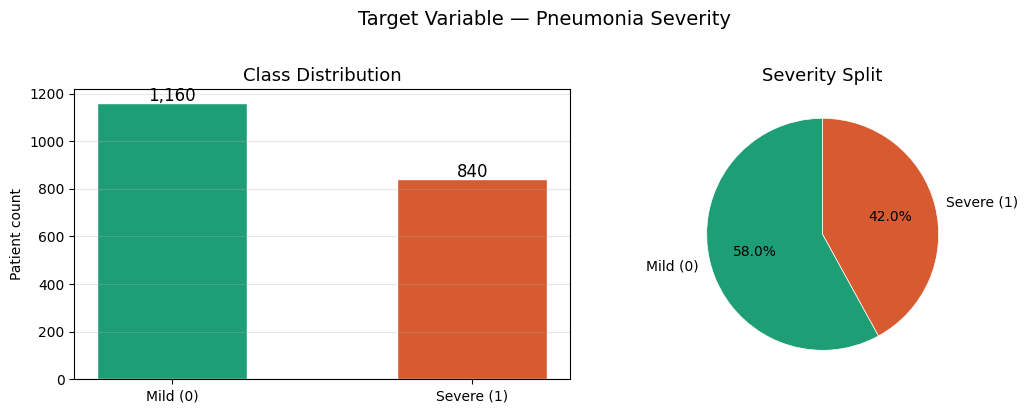

Mild   : 1160 (58.0%)
Severe : 840 (42.0%)


In [31]:
# TARGET DISTRIBUTION
counts = df["severity"].value_counts().sort_index()
labels = ["Mild (0)", "Severe (1)"]
colors = ["#1D9E75", "#D85A30"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor="white")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10, f"{val:,}", ha="center", fontsize=12)
axes[0].set_title("Class Distribution", fontsize=13)
axes[0].set_ylabel("Patient count")
axes[0].grid(axis="y", alpha=0.3)

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"linewidth":0.5,"edgecolor":"white"})
axes[1].set_title("Severity Split", fontsize=13)

plt.suptitle("Target Variable — Pneumonia Severity", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Mild   : {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Severe : {counts[1]} ({counts[1]/len(df)*100:.1f}%)")

Columns with missing values:
                         count  percent
temperature_celsius         80     4.00
spo2_percent                80     4.00
wbc_count_x10               79     3.95
blood_pressure_systolic     80     4.00


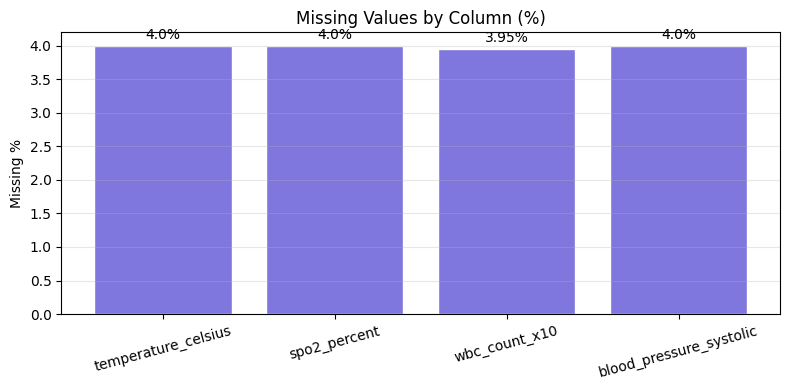

In [32]:
# MISSING VALUES 
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "percent": missing_pct})
missing_df = missing_df[missing_df["count"] > 0]

print("Columns with missing values:")
print(missing_df)

plt.figure(figsize=(8, 4))
bars = plt.bar(missing_df.index, missing_df["percent"], color="#7F77DD", edgecolor="white")
for bar, val in zip(bars, missing_df["percent"]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1, f"{val}%", ha="center", fontsize=10)
plt.title("Missing Values by Column (%)")
plt.ylabel("Missing %")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

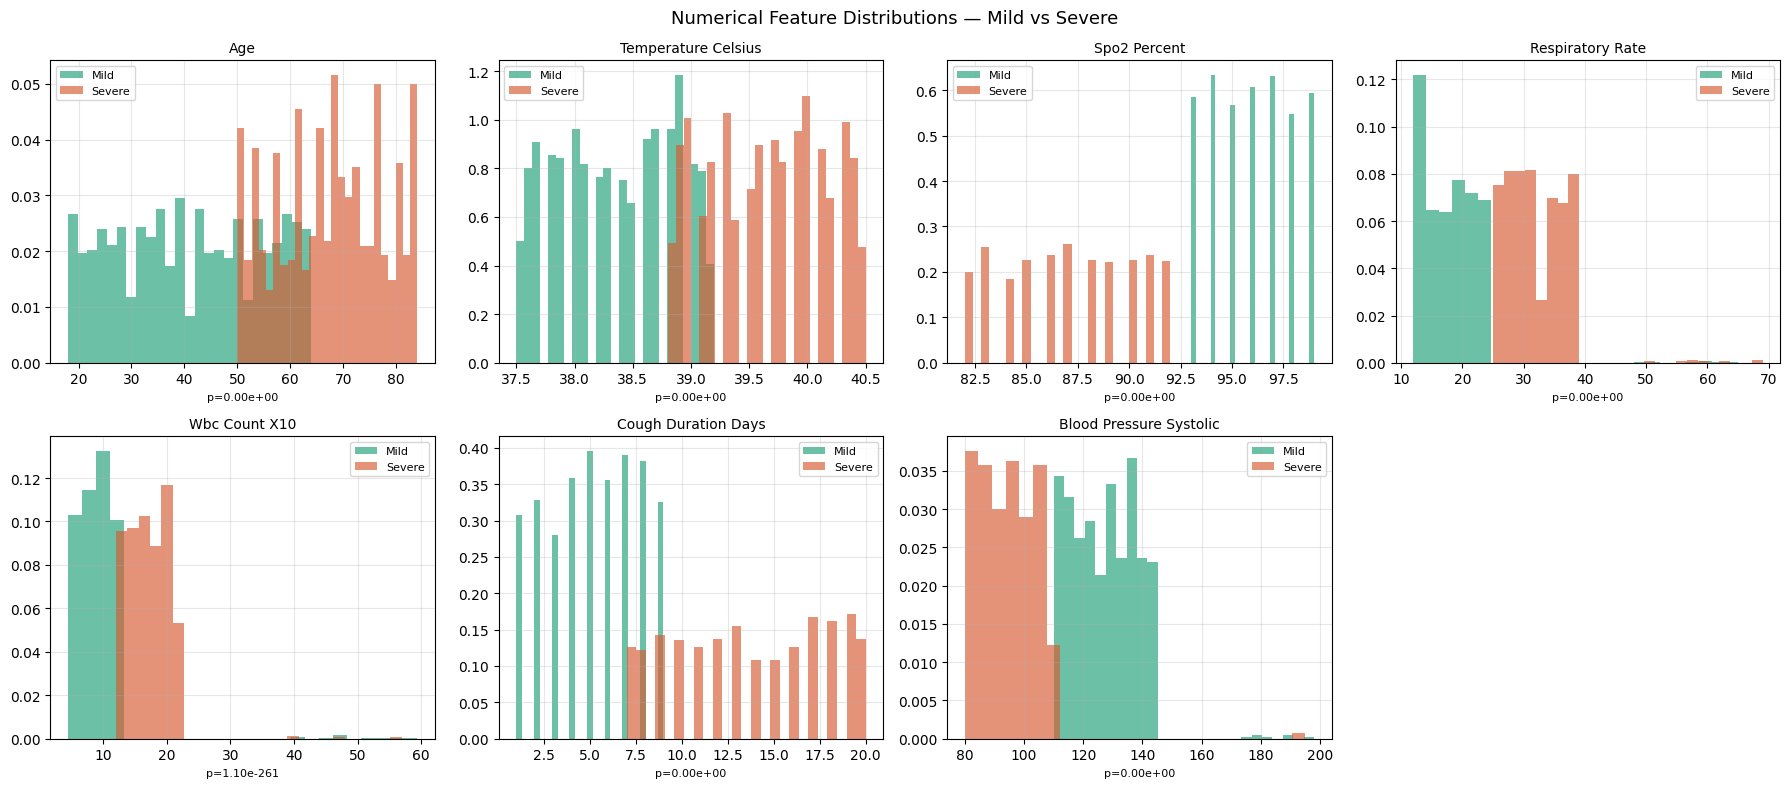

In [33]:
#NUMERICAL FEATURE DISTRIBUTIONS BY SEVERITY 
num_cols = ["age", "temperature_celsius", "spo2_percent",
            "respiratory_rate", "wbc_count_x10",
            "cough_duration_days", "blood_pressure_systolic"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    mild   = df[df["severity"] == 0][col].dropna()
    severe = df[df["severity"] == 1][col].dropna()
    axes[i].hist(mild,   bins=25, alpha=0.65, color="#1D9E75", label="Mild",   density=True)
    axes[i].hist(severe, bins=25, alpha=0.65, color="#D85A30", label="Severe", density=True)
    axes[i].set_title(col.replace("_"," ").title(), fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)
    # t-test p-value
    t, p = stats.ttest_ind(mild, severe)
    axes[i].set_xlabel(f"p={p:.2e}", fontsize=8)

axes[-1].axis("off")
plt.suptitle("Numerical Feature Distributions — Mild vs Severe", fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\noman\AppData\Local\Temp\ipykernel_76216\3548941685.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=["Mild","Severe"], patch_artist=True,
C:\Users\noman\AppData\Local\Temp\ipykernel_76216\3548941685.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=["Mild","Severe"], patch_artist=True,
C:\Users\noman\AppData\Local\Temp\ipykernel_76216\3548941685.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=["Mild","Severe"], patch_artist=True,
C:\Users\noman\AppData\Local\Temp\ipykernel_76216\3548941685.py:8: Mat

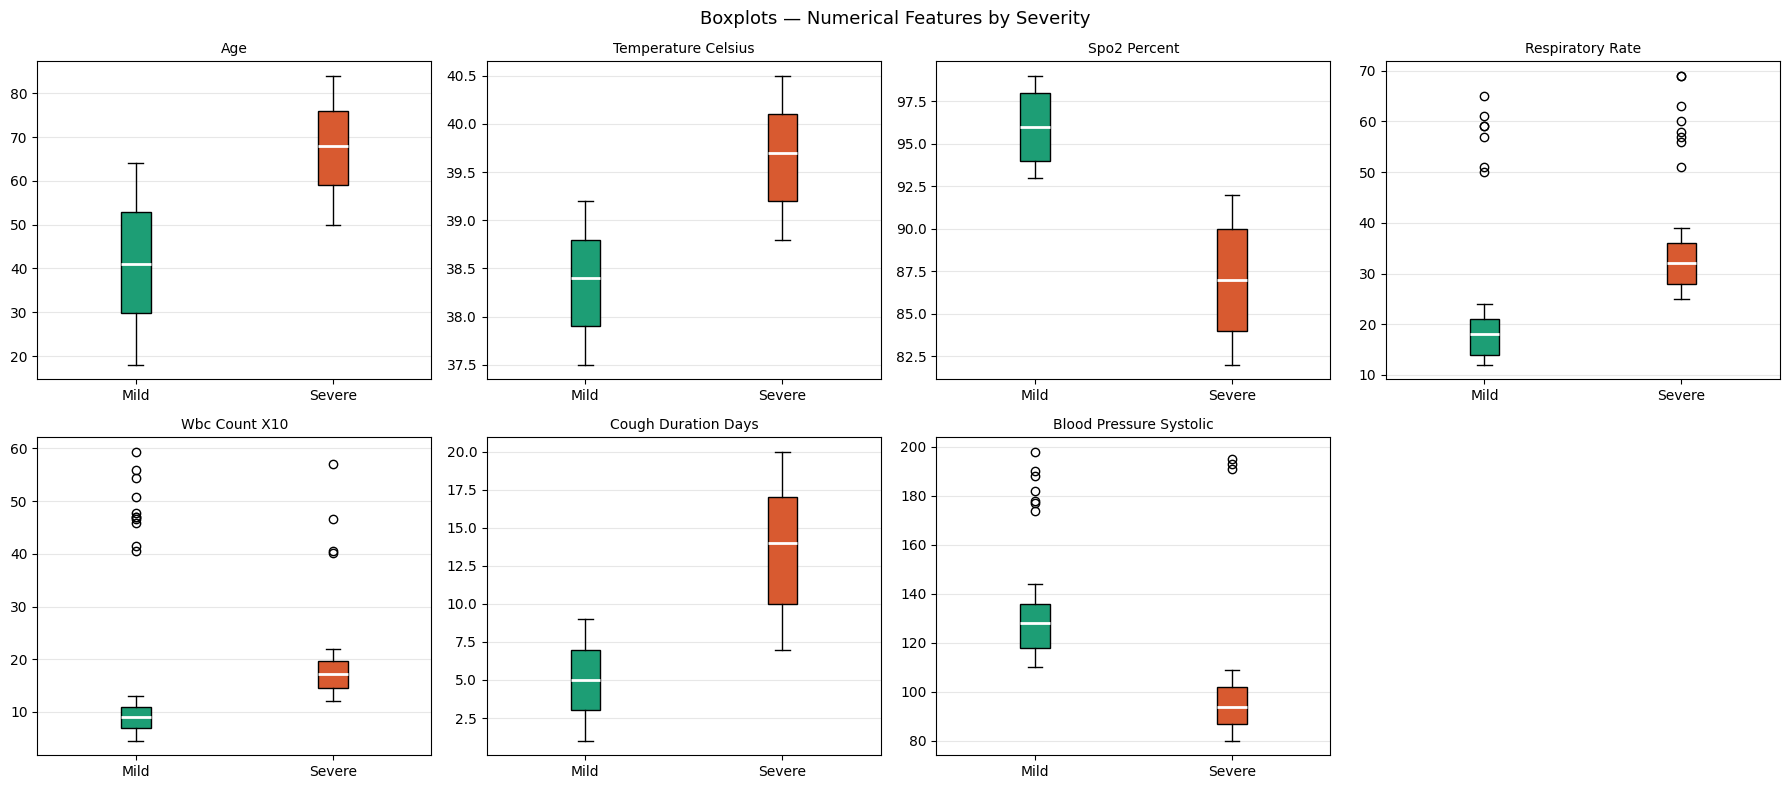

In [34]:
# BOXPLOTS
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = [df[df["severity"]==0][col].dropna(),
            df[df["severity"]==1][col].dropna()]
    bp = axes[i].boxplot(data, labels=["Mild","Severe"], patch_artist=True,
                          medianprops=dict(color="white", linewidth=2))
    bp["boxes"][0].set_facecolor("#1D9E75")
    bp["boxes"][1].set_facecolor("#D85A30")
    axes[i].set_title(col.replace("_"," ").title(), fontsize=10)
    axes[i].grid(axis="y", alpha=0.3)

axes[-1].axis("off")
plt.suptitle("Boxplots — Numerical Features by Severity", fontsize=13)
plt.tight_layout()
plt.show()

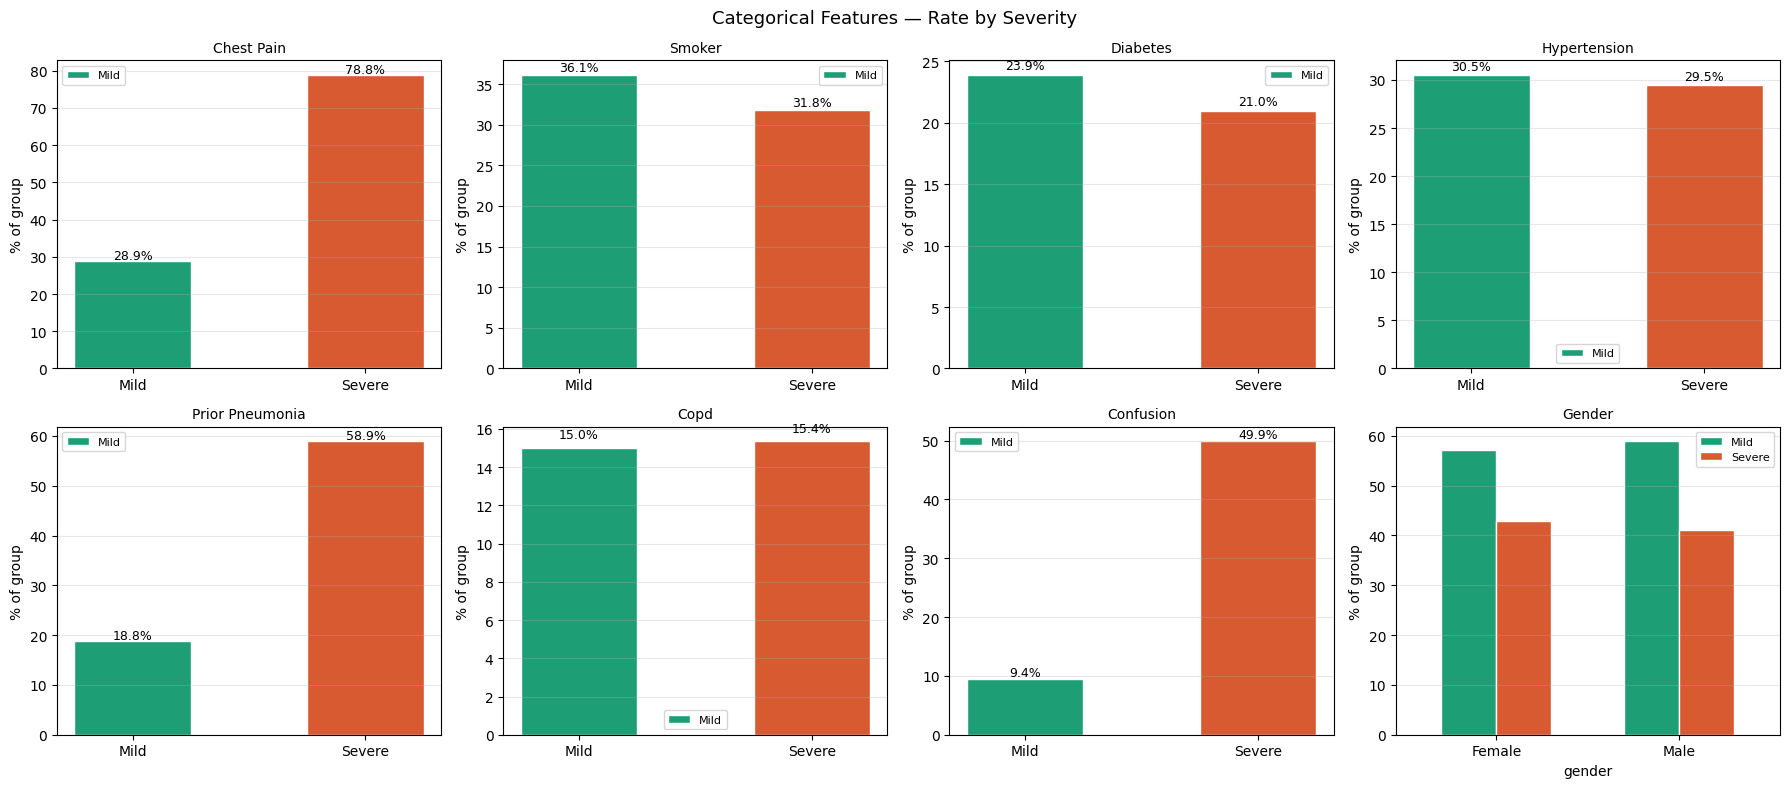

In [35]:
# CATEGORICAL FEATURE RATES BY SEVERITY 
cat_cols = ["chest_pain","smoker","diabetes","hypertension",
            "prior_pneumonia","copd","confusion","gender"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col == "gender":
        ct = pd.crosstab(df[col], df["severity"], normalize="index") * 100
        ct.plot(kind="bar", ax=axes[i], color=["#1D9E75","#D85A30"],
                edgecolor="white", width=0.6)
        axes[i].tick_params(axis="x", rotation=0)
    else:
        rates = df.groupby("severity")[col].mean() * 100
        bars = axes[i].bar(["Mild","Severe"], rates.values,
                            color=["#1D9E75","#D85A30"], edgecolor="white", width=0.5)
        for bar, val in zip(bars, rates.values):
            axes[i].text(bar.get_x()+bar.get_width()/2,
                         bar.get_height()+0.5, f"{val:.1f}%", ha="center", fontsize=9)
    axes[i].set_title(col.replace("_"," ").title(), fontsize=10)
    axes[i].set_ylabel("% of group")
    axes[i].grid(axis="y", alpha=0.3)
    axes[i].legend(["Mild","Severe"], fontsize=8)

plt.suptitle("Categorical Features — Rate by Severity", fontsize=13)
plt.tight_layout()
plt.show()

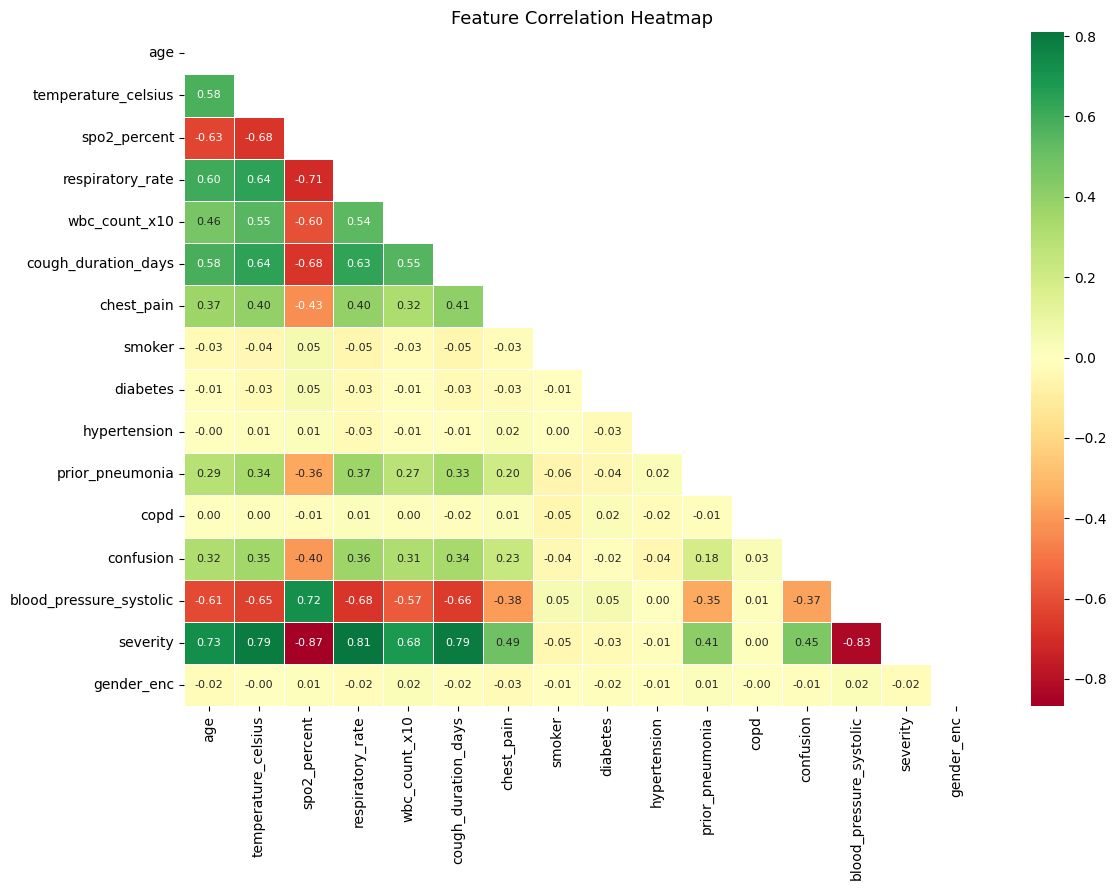

Top features correlated with severity:
spo2_percent               0.866975
blood_pressure_systolic    0.828950
respiratory_rate           0.809374
cough_duration_days        0.792929
temperature_celsius        0.790413
age                        0.727584
wbc_count_x10              0.680721
chest_pain                 0.492872
Name: severity, dtype: float64


In [36]:
#  CORRELATION HEATMAP 
le = LabelEncoder()
df_corr = df.copy()
df_corr["gender_enc"] = le.fit_transform(df_corr["gender"])
df_corr.drop(columns=["patient_id","gender"], inplace=True)

plt.figure(figsize=(12, 9))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5,
            annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.show()

print("Top features correlated with severity:")
print(corr["severity"].drop("severity").abs()
      .sort_values(ascending=False).head(8))

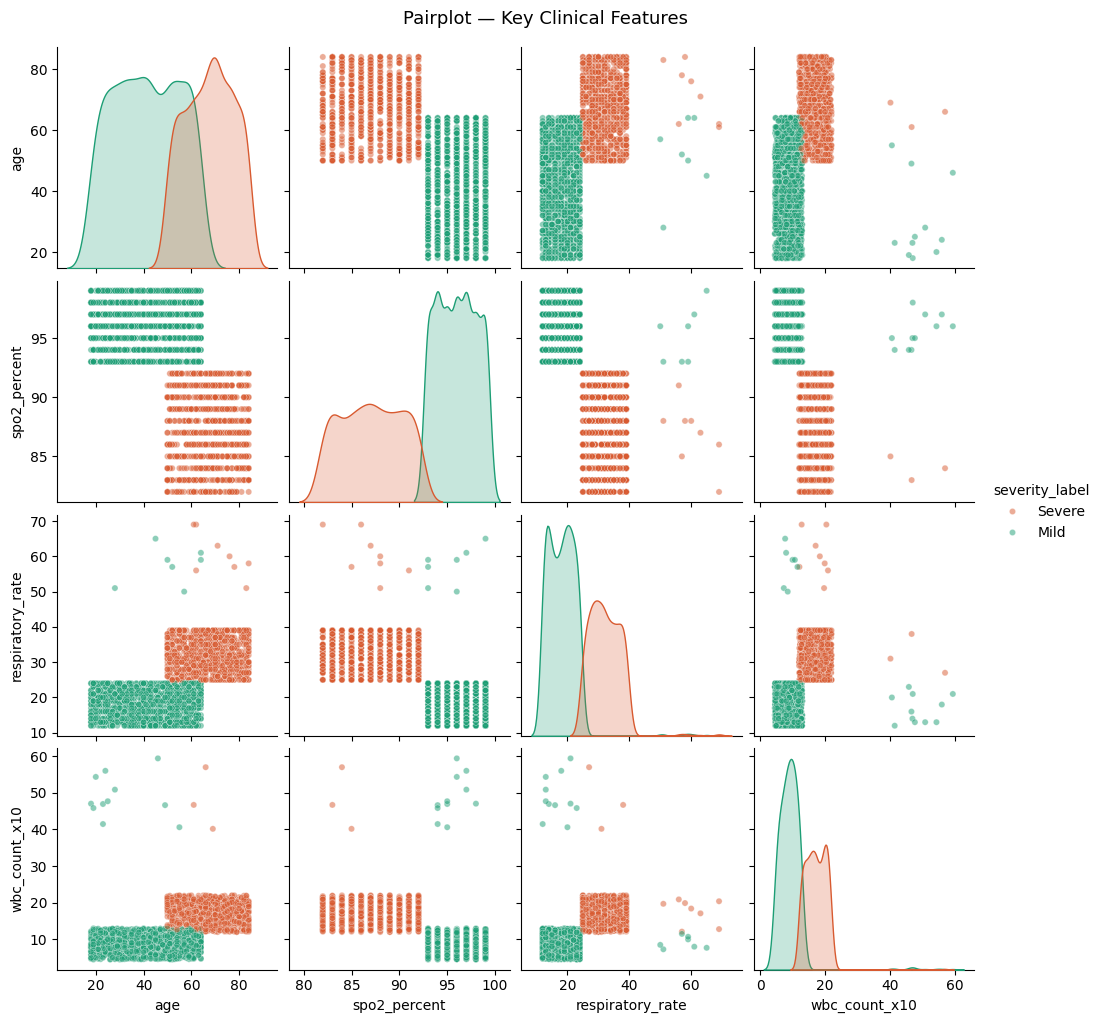

In [37]:
# PAIRPLOT
key_feats = ["age","spo2_percent","respiratory_rate","wbc_count_x10","severity"]
df_pair   = df[key_feats].dropna()
df_pair["severity_label"] = df_pair["severity"].map({0:"Mild",1:"Severe"})

g = sns.pairplot(df_pair.drop(columns="severity"),
                 hue="severity_label",
                 palette={"Mild":"#1D9E75","Severe":"#D85A30"},
                 diag_kind="kde", plot_kws={"alpha":0.5, "s":20})
g.fig.suptitle("Pairplot — Key Clinical Features", y=1.02, fontsize=13)
plt.show()

In [38]:
df_clean = df.drop(columns=["patient_id"]).copy()

# IMPUTE MISSING using median
impute_cols = ["temperature_celsius","wbc_count_x10",
               "spo2_percent","blood_pressure_systolic"]
for col in impute_cols:
    missing = df_clean[col].isnull().sum()
    median  = df_clean[col].median()
    df_clean[col].fillna(median, inplace=True)
    print(f"  '{col}': imputed {missing} missing → median = {median:.2f}")

print(f"\nMissing after imputation: {df_clean.isnull().sum().sum()}")

  'temperature_celsius': imputed 80 missing → median = 38.90
  'wbc_count_x10': imputed 79 missing → median = 11.80
  'spo2_percent': imputed 80 missing → median = 93.50
  'blood_pressure_systolic': imputed 80 missing → median = 114.00

Missing after imputation: 0


C:\Users\noman\AppData\Local\Temp\ipykernel_76216\3668536963.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median, inplace=True)
C:\Users\noman\AppData\Local\Temp\ipykernel_76216\3668536963.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [39]:
# OUTLIER REMOVAL (IQR)
def remove_outliers(df, cols):
    original = len(df)
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR     = Q3 - Q1
        lo, hi  = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        before  = len(df)
        df      = df[(df[col] >= lo) & (df[col] <= hi)]
        print(f"  '{col}': removed {before-len(df)} outliers "
              f"(valid range: {lo:.1f} – {hi:.1f})")
    print(f"\nRows: {original} → {len(df)}  "
          f"({original-len(df)} removed)")
    return df.reset_index(drop=True)

df_clean = remove_outliers(
    df_clean,
    ["wbc_count_x10","respiratory_rate","blood_pressure_systolic"])

  'wbc_count_x10': removed 15 outliers (valid range: -2.5 – 27.1)
  'respiratory_rate': removed 15 outliers (valid range: -2.5 – 49.5)
  'blood_pressure_systolic': removed 7 outliers (valid range: 50.0 – 178.0)

Rows: 2000 → 1963  (37 removed)


In [40]:
# ENCODE GENDER 
le = LabelEncoder()
df_clean["gender"] = le.fit_transform(df_clean["gender"])
print(f"Gender encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"\nFinal clean shape: {df_clean.shape}")
df_clean.head()

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Final clean shape: (1963, 16)


,age,gender,temperature_celsius,spo2_percent,respiratory_rate,wbc_count_x10,cough_duration_days,chest_pain,smoker,diabetes,hypertension,prior_pneumonia,copd,confusion,blood_pressure_systolic,severity
0,77,0,39.0,85.0,28,15.5,12,1,0,0,0,0,0,1,107.0,1
1,21,1,37.9,96.0,20,7.4,7,0,1,0,0,0,0,0,132.0,0
2,57,1,39.0,96.0,20,7.0,1,1,1,1,0,0,0,0,135.0,0
3,33,0,38.4,99.0,12,6.5,9,1,1,0,1,1,0,0,133.0,0
4,63,1,39.9,92.0,37,18.6,12,1,0,0,0,0,0,0,96.0,1


In [41]:
df_feat = df_clean.copy()

# SpO2 to Respiratory Rate ratio
df_feat["spo2_rr_ratio"] = (
    df_feat["spo2_percent"] / df_feat["respiratory_rate"]).round(3)

# Fever flag (WHO threshold)
df_feat["fever_flag"] = (df_feat["temperature_celsius"] >= 38.5).astype(int)

# CURB-65 score (clinical pneumonia severity tool)
# C=confusion, U=urea(approx WBC>15), R=RR>30, B=BP<90, 65=age>=65
df_feat["curb65_score"] = (
    df_feat["confusion"].astype(int) +
    (df_feat["wbc_count_x10"] > 15).astype(int) +   # proxy for urea
    (df_feat["respiratory_rate"] > 30).astype(int) +
    (df_feat["blood_pressure_systolic"] < 90).astype(int) +
    (df_feat["age"] >= 65).astype(int)
)

# Age group bins
df_feat["age_group"] = pd.cut(
    df_feat["age"], bins=[0,30,50,65,100],
    labels=[0,1,2,3]).astype(int)

# Total comorbidity count
comorbidity_cols = ["diabetes","hypertension","copd",
                    "smoker","prior_pneumonia","chest_pain","confusion"]
df_feat["comorbidity_count"] = df_feat[comorbidity_cols].sum(axis=1)

# Low blood pressure flag (ICU criterion)
df_feat["bp_low_flag"] = (df_feat["blood_pressure_systolic"] < 90).astype(int)

NEW_FEATS = ["spo2_rr_ratio","fever_flag","curb65_score",
             "age_group","comorbidity_count","bp_low_flag"]
print("New features summary:")
print(df_feat[NEW_FEATS].describe().round(3))

New features summary:
       spo2_rr_ratio  fever_flag  curb65_score  age_group  comorbidity_count  \
count       1963.000    1963.000      1963.000   1963.000           1963.000   
mean           4.434       0.696         1.180      1.675              2.141   
std            1.714       0.460         1.476      1.008              1.258   
min            2.103       0.000         0.000      0.000              0.000   
25%            2.875       0.000         0.000      1.000              1.000   
50%            4.227       1.000         0.000      2.000              2.000   
75%            5.647       1.000         2.000      2.000              3.000   
max            8.250       1.000         5.000      3.000              7.000   

       bp_low_flag  
count     1963.000  
mean         0.136  
std          0.342  
min          0.000  
25%          0.000  
50%          0.000  
75%          0.000  
max          1.000  


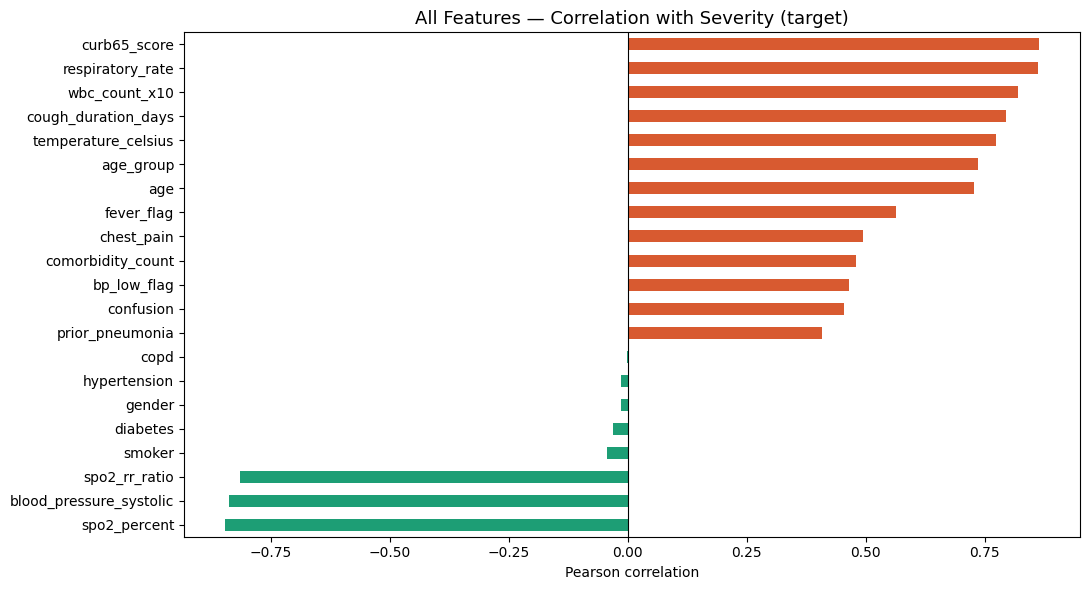

In [42]:
# FEATURE IMPORTANCE PREVIEW (correlation with target) 
all_feats = (["age","temperature_celsius","spo2_percent","respiratory_rate",
               "wbc_count_x10","cough_duration_days","blood_pressure_systolic",
               "chest_pain","smoker","diabetes","hypertension","prior_pneumonia",
               "copd","confusion","gender"] + NEW_FEATS)

corr_vals = df_feat[all_feats + ["severity"]].corr()["severity"].drop("severity")

plt.figure(figsize=(11, 6))
bar_colors = ["#D85A30" if v > 0 else "#1D9E75"
              for v in corr_vals.sort_values()]
corr_vals.sort_values().plot(kind="barh", color=bar_colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("All Features — Correlation with Severity (target)", fontsize=13)
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

In [43]:
# FEATURE COLUMNS 
FEATURE_COLS = all_feats.copy()
NUM_SCALE    = ["age","temperature_celsius","spo2_percent","respiratory_rate",
                "wbc_count_x10","cough_duration_days","blood_pressure_systolic",
                "spo2_rr_ratio","curb65_score","comorbidity_count"]

X = df_feat[FEATURE_COLS].copy()
y = df_feat["severity"]

# Scale numerical columns
scaler   = StandardScaler()
X_scaled = X.copy()
X_scaled[NUM_SCALE] = scaler.fit_transform(X[NUM_SCALE])

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y)

# SMOTE on training set only
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Features         : {len(FEATURE_COLS)}")
print(f"Train (raw)      : {X_train.shape}  | Severe={y_train.sum()}")
print(f"Train (SMOTE)    : {X_train_sm.shape}  | Severe={y_train_sm.sum()}")
print(f"Test             : {X_test.shape}   | Severe={y_test.sum()}")

Features         : 21
Train (raw)      : (1570, 21)  | Severe=660
Train (SMOTE)    : (1820, 21)  | Severe=910
Test             : (393, 21)   | Severe=165


In [44]:
# ── XGBOOST — FULL GRIDSEARCHCV ──────────────────────────────
print("Tuning XGBoost — please wait...")

xgb_param_grid = {
    "n_estimators"  : [100, 200, 300],
    "max_depth"     : [3, 5, 7],
    "learning_rate" : [0.01, 0.05, 0.1],
    "subsample"     : [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
    "min_child_weight": [1, 3],
}

xgb_cv = GridSearchCV(
    XGBClassifier(random_state=SEED, eval_metric="logloss",
                  use_label_encoder=False, n_jobs=-1),
    xgb_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    refit=True,
)
xgb_cv.fit(X_train_sm, y_train_sm)
best_xgb = xgb_cv.best_estimator_

print(f"\nBest XGBoost params:")
for k,v in xgb_cv.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV F1 : {xgb_cv.best_score_:.4f}")

Tuning XGBoost — please wait...
Fitting 5 folds for each of 486 candidates, totalling 2430 fits

Best XGBoost params:
  colsample_bytree: 0.7
  learning_rate: 0.01
  max_depth: 3
  min_child_weight: 1
  n_estimators: 100
  subsample: 0.7
Best CV F1 : 1.0000


c:\Users\noman\anaconda3\envs\mlai\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:59:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [45]:
#RANDOM FOREST GRIDSEARCHCV 
print("Tuning Random Forest — please wait...")

rf_param_grid = {
    "n_estimators"      : [100, 200, 300],
    "max_depth"         : [None, 10, 20, 30],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf"  : [1, 2, 4],
    "max_features"      : ["sqrt", "log2"],
}

rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=SEED, class_weight="balanced", n_jobs=-1),
    rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    refit=True,
)
rf_cv.fit(X_train_sm, y_train_sm)
best_rf = rf_cv.best_estimator_

print(f"\nBest Random Forest params:")
for k,v in rf_cv.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV F1 : {rf_cv.best_score_:.4f}")

Tuning Random Forest — please wait...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits


c:\Users\noman\anaconda3\envs\mlai\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Random Forest params:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100
Best CV F1 : 1.0000


In [46]:
#CLASSIFICATION REPORTS 
results = {}
for name, model in [("XGBoost", best_xgb), ("Random Forest", best_rf)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "model"  : model,
        "y_pred" : y_pred,
        "y_prob" : y_prob,
        "f1"     : f1_score(y_test, y_pred),
        "auc"    : roc_auc_score(y_test, y_prob),
        "prec"   : precision_score(y_test, y_pred),
        "rec"    : recall_score(y_test, y_pred),
    }
    print(f"\n{'='*52}")
    print(f"  {name}")
    print(f"{'='*52}")
    print(classification_report(y_test, y_pred,
                                 target_names=["Mild","Severe"]))
    print(f"  ROC-AUC : {results[name]['auc']:.4f}")


  XGBoost
              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00       228
      Severe       1.00      1.00      1.00       165

    accuracy                           1.00       393
   macro avg       1.00      1.00      1.00       393
weighted avg       1.00      1.00      1.00       393

  ROC-AUC : 1.0000

  Random Forest
              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00       228
      Severe       1.00      1.00      1.00       165

    accuracy                           1.00       393
   macro avg       1.00      1.00      1.00       393
weighted avg       1.00      1.00      1.00       393

  ROC-AUC : 1.0000


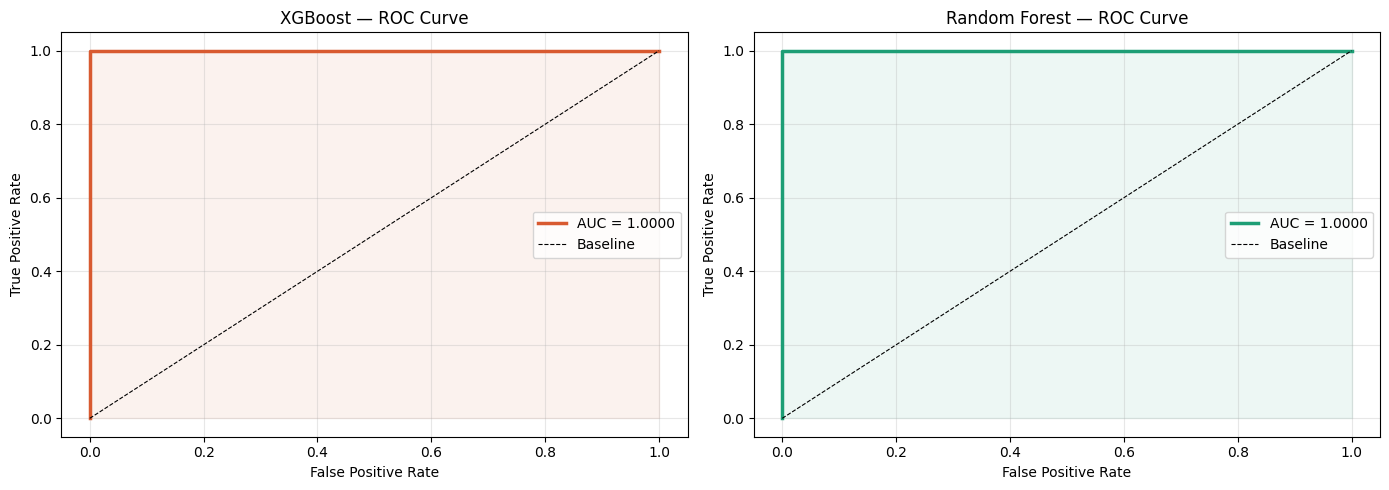

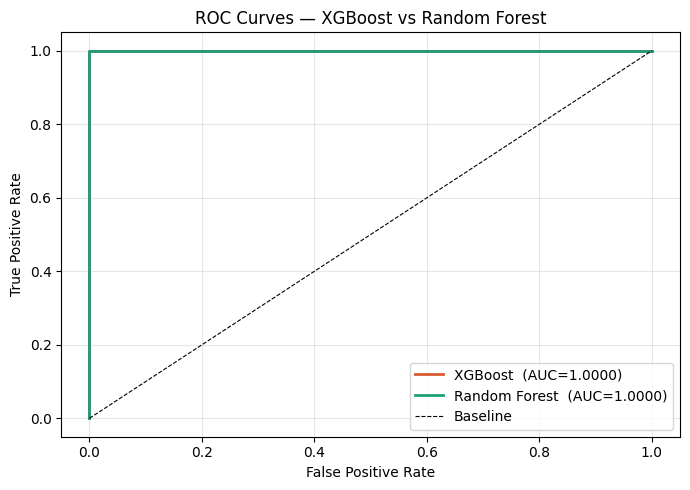

In [47]:
# ROC CURVES
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {"XGBoost":"#D85A30", "Random Forest":"#1D9E75"}

# Individual ROC curves
for ax, (name, res) in zip(axes, results.items()):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, color=palette[name], linewidth=2.5,
            label=f"AUC = {res['auc']:.4f}")
    ax.fill_between(fpr, tpr, alpha=0.08, color=palette[name])
    ax.plot([0,1],[0,1],"k--",linewidth=0.8,label="Baseline")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{name} — ROC Curve")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WEIGHT_DIR,"roc_curves.png"), dpi=150)
plt.show()

# Combined plot
plt.figure(figsize=(7,5))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    plt.plot(fpr, tpr, color=palette[name], linewidth=2,
             label=f"{name}  (AUC={res['auc']:.4f})")
plt.plot([0,1],[0,1],"k--",linewidth=0.8,label="Baseline")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — XGBoost vs Random Forest")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(WEIGHT_DIR,"roc_combined.png"), dpi=150)
plt.show()

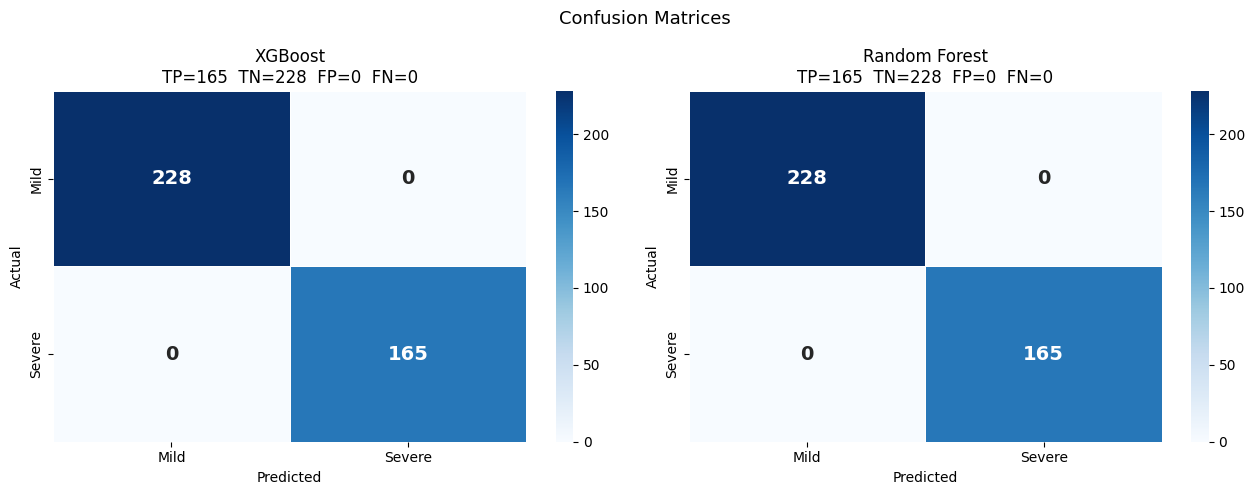

In [48]:
#CONFUSION MATRICES 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Mild","Severe"],
                yticklabels=["Mild","Severe"],
                linewidths=0.5, ax=ax,
                annot_kws={"size":14, "weight":"bold"})
    tn,fp,fn,tp = cm.ravel()
    ax.set_title(f"{name}\nTP={tp}  TN={tn}  FP={fp}  FN={fn}")
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrices", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(WEIGHT_DIR,"confusion_matrices.png"), dpi=150)
plt.show()

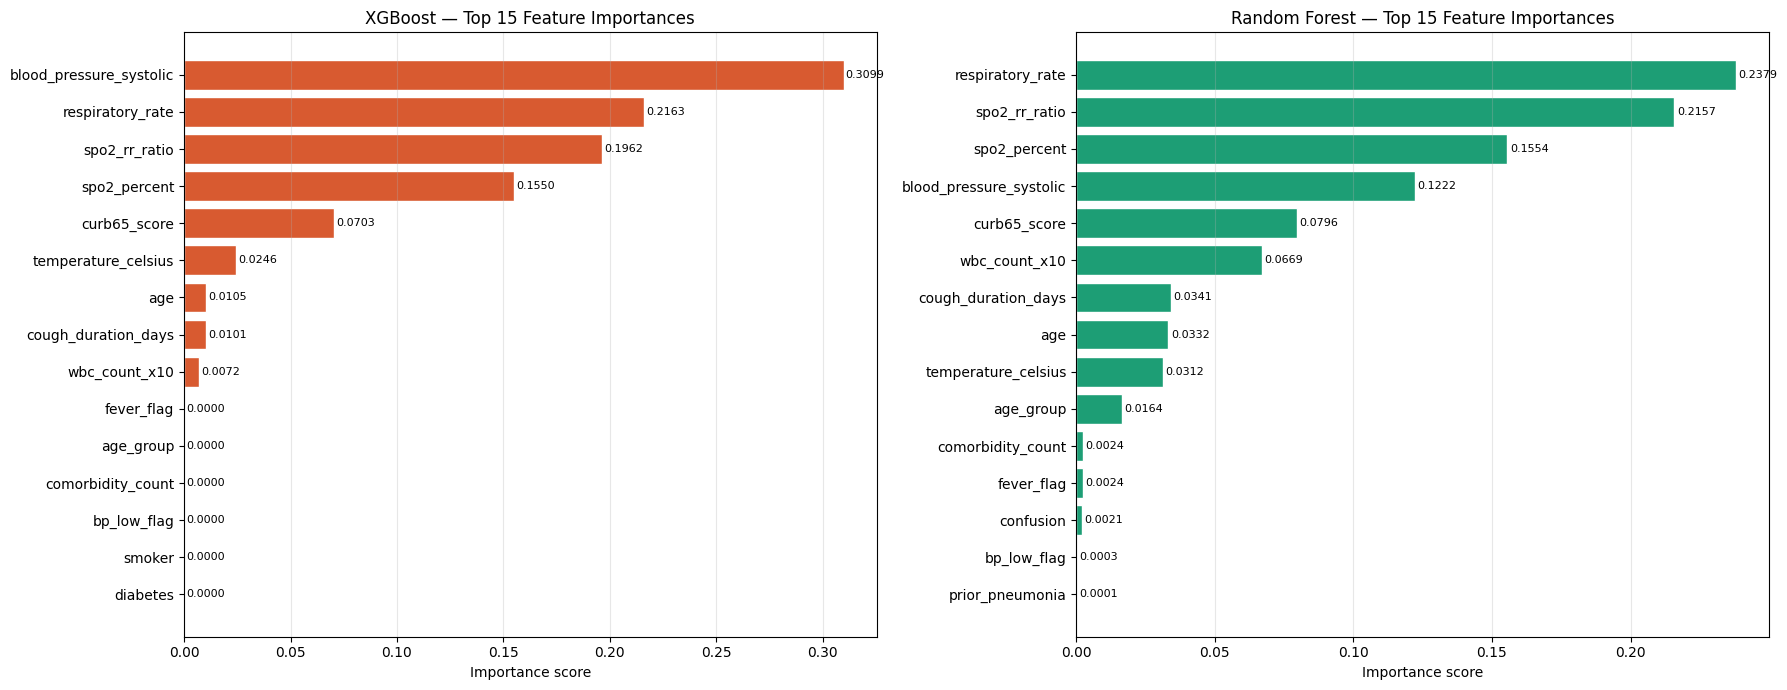

In [49]:
#FEATURE IMPORTANCE
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (name, res) in zip(axes, results.items()):
    feat_df = pd.DataFrame({
        "feature"    : FEATURE_COLS,
        "importance" : res["model"].feature_importances_
    }).sort_values("importance", ascending=True).tail(15)

    bars = ax.barh(feat_df["feature"], feat_df["importance"],
                   color=palette[name], edgecolor="white")
    ax.set_title(f"{name} — Top 15 Feature Importances", fontsize=12)
    ax.set_xlabel("Importance score")
    ax.grid(axis="x", alpha=0.3)
    # add value labels
    for bar in bars:
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{bar.get_width():.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(WEIGHT_DIR,"feature_importance.png"), dpi=150)
plt.show()

c:\Users\noman\anaconda3\envs\mlai\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\noman\anaconda3\envs\mlai\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\noman\anaconda3\envs\mlai\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\noman\anaconda3\envs\mlai\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_en

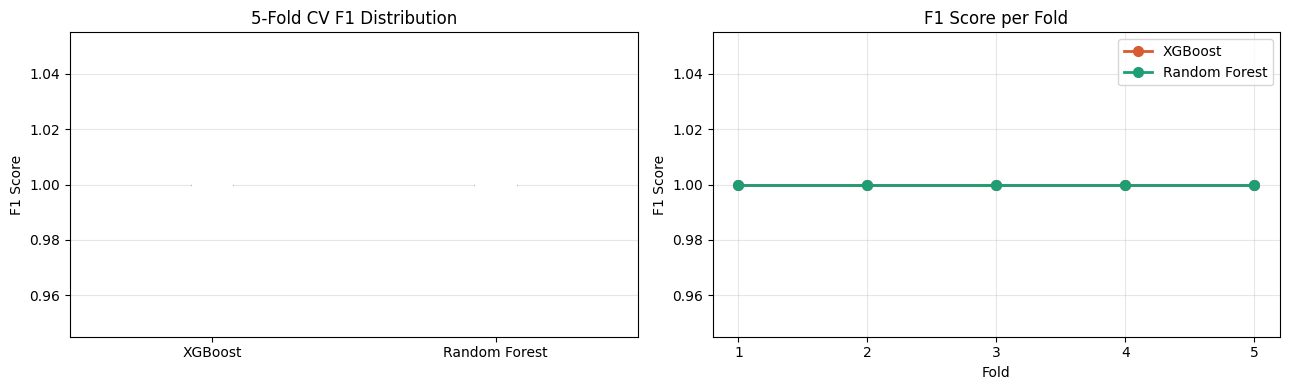

XGBoost CV F1    : 1.0000 ± 0.0000
Random Forest F1 : 1.0000 ± 0.0000


In [51]:
#CROSS-VALIDATION COMPARISON
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
xgb_cv_scores = cross_val_score(best_xgb, X_scaled, y, cv=cv, scoring="f1")
rf_cv_scores  = cross_val_score(best_rf,  X_scaled, y, cv=cv, scoring="f1")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Boxplot
bp = axes[0].boxplot(
    [xgb_cv_scores, rf_cv_scores],
    labels=["XGBoost","Random Forest"],
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2.5))
bp["boxes"][0].set_facecolor("#D85A30")
bp["boxes"][1].set_facecolor("#1D9E75")
axes[0].set_title("5-Fold CV F1 Distribution")
axes[0].set_ylabel("F1 Score")
axes[0].grid(axis="y", alpha=0.3)

# Score per fold
folds = range(1, 6)
axes[1].plot(folds, xgb_cv_scores, "o-", color="#D85A30",
             linewidth=2, label="XGBoost", markersize=7)
axes[1].plot(folds, rf_cv_scores,  "o-", color="#1D9E75",
             linewidth=2, label="Random Forest", markersize=7)
axes[1].set_title("F1 Score per Fold")
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("F1 Score")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xticks(folds)

plt.tight_layout()
plt.savefig(os.path.join(WEIGHT_DIR,"cv_comparison.png"), dpi=150)
plt.show()

print(f"XGBoost CV F1    : {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")
print(f"Random Forest F1 : {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

In [53]:
# FINAL COMPARISON TABLE 
print("\n" + "="*60)
print(f"  {'Metric':<22} {'XGBoost':>15} {'Random Forest':>15}")
print("="*60)
metrics = [
    ("F1 Score (test)",    "f1"),
    ("ROC-AUC (test)",     "auc"),
    ("Precision",          "prec"),
    ("Recall",             "rec"),
]
for label, key in metrics:
    xv = results["XGBoost"][key]
    rv = results["Random Forest"][key]
    winner = " ←" if xv >= rv else ""
    winner2 = " ←" if rv > xv else ""
    print(f"  {label:<22} {xv:>15.4f}{winner:>2} {rv:>13.4f}{winner2}")

print(f"  {'CV F1 Mean':<22} {xgb_cv_scores.mean():>15.4f}  {rf_cv_scores.mean():>13.4f}")
print("="*60)

best_name  = ("XGBoost"
              if results["XGBoost"]["f1"] >= results["Random Forest"]["f1"]
              else "Random Forest")
best_model = results[best_name]["model"]
print(f"\nWinner → {best_name} (will be pickled)")


  Metric                         XGBoost   Random Forest
  F1 Score (test)                 1.0000 ←        1.0000
  ROC-AUC (test)                  1.0000 ←        1.0000
  Precision                       1.0000 ←        1.0000
  Recall                          1.0000 ←        1.0000
  CV F1 Mean                      1.0000         1.0000

Winner → XGBoost (will be pickled)


In [54]:
# Pickling
model_pkl  = os.path.join(WEIGHT_DIR, "pneumonia_risk_model.pkl")
scaler_pkl = os.path.join(WEIGHT_DIR, "pneumonia_scaler.pkl")
meta_pkl   = os.path.join(WEIGHT_DIR, "pneumonia_meta.pkl")

with open(model_pkl,  "wb") as f: pickle.dump(best_model, f)
with open(scaler_pkl, "wb") as f: pickle.dump(scaler, f)
with open(meta_pkl,   "wb") as f:
    pickle.dump({
        "feature_cols" : FEATURE_COLS,
        "num_scale"    : NUM_SCALE,
        "class_names"  : ["Mild","Severe"],
        "model_name"   : best_name,
        "best_f1"      : round(results[best_name]["f1"],  4),
        "best_auc"     : round(results[best_name]["auc"], 4),
        "best_params"  : (xgb_cv.best_params_
                          if best_name == "XGBoost"
                          else rf_cv.best_params_),
    }, f)

print(f"Saved → {model_pkl}")
print(f"Saved → {scaler_pkl}")
print(f"Saved → {meta_pkl}")

Saved → f:\Naman\medvision_ai\models\weights\pneumonia_risk_model.pkl
Saved → f:\Naman\medvision_ai\models\weights\pneumonia_scaler.pkl
Saved → f:\Naman\medvision_ai\models\weights\pneumonia_meta.pkl
